In [1]:
STEP = 7
LEARNING_RATE = 1e-4 * 0.5 ** (STEP - 1)
BATCH_SIZE = 8
EPOCHS = 200
PATIENCE = 50
print(f"Learning rate: {LEARNING_RATE}, Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")

Learning rate: 1.5625e-06, Batch size: 8, Epochs: 200


In [2]:
from models.dataset import ImageDataset
from torch.utils.data import DataLoader
train_dataset = ImageDataset(hr_root=r"Data\DIV2K_train_HR", lr_root=r"Data\DIV2K_train_LR_bicubic\X4", lr_suffix="x4", ratio=4)
test_dataset = ImageDataset(hr_root=r"Data\valid_HR", lr_root=r"Data\valid_LR", lr_suffix="", ratio=4, train=False)
final_test_dataset = ImageDataset(hr_root=r"Data\DIV2K_valid_HR", lr_root=r"Data\DIV2K_valid_LR_bicubic\X4", lr_suffix="x4", ratio=4, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)
final_test_loader = DataLoader(final_test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)

In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
import os
from models.faster_rcan import FasterRCAN
import torch.nn as nn
model = FasterRCAN()
model_weights = f"weights/faster_rcan_{STEP:02d}.pth"
autocast = torch.autocast(device_type=device, dtype=torch.bfloat16)


if os.path.exists(model_weights):
    model.load_state_dict(torch.load(model_weights, map_location=device))
elif STEP > 1:
    model_weights = f"weights/faster_rcan_{STEP-1:02d}.pth"
    if os.path.exists(model_weights):
        model.load_state_dict(torch.load(model_weights, map_location=device))
model.to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
num_params = count_parameters(model)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 7334371


In [5]:
from tqdm import tqdm
best_loss = float("inf")
# Initial validation
model.eval()
running_test_loss = 0.0
with torch.inference_mode():
    for lr_images, hr_images in tqdm(test_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        with autocast:
            outputs = model(lr_images)
            loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
test_loss = running_test_loss / len(test_loader)

if test_loss < best_loss:
    best_loss = test_loss
    torch.save(model.state_dict(), model_weights)
print(f"Initial Best Loss: {best_loss:.9f}")

100%|██████████| 200/200 [01:08<00:00,  2.92it/s]


Initial Best Loss: 0.024512463


100%|██████████| 200/200 [01:08<00:00,  2.91it/s]


Epoch [1/200] Train Loss: 0.025267480 Val Loss: 0.024546246 Best: 0.024512463
Training time: 127.48s
--------------------------------------------------


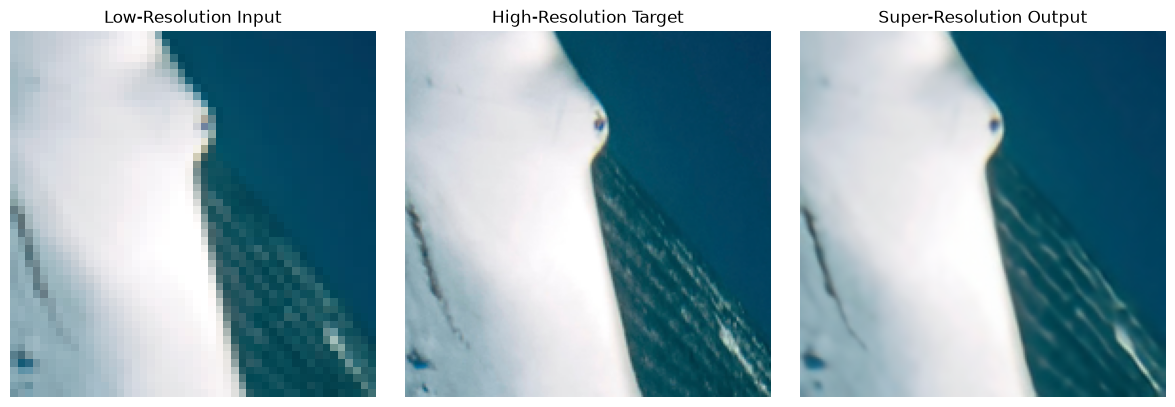

100%|██████████| 200/200 [01:11<00:00,  2.81it/s]


Epoch [2/200] Train Loss: 0.025182248 Val Loss: 0.024565639 Best: 0.024512463
Training time: 256.15s
--------------------------------------------------


100%|██████████| 200/200 [01:11<00:00,  2.79it/s]


Epoch [3/200] Train Loss: 0.025699369 Val Loss: 0.024562666 Best: 0.024512463
Training time: 379.58s
--------------------------------------------------


100%|██████████| 200/200 [01:11<00:00,  2.79it/s]


Epoch [4/200] Train Loss: 0.024561561 Val Loss: 0.024542894 Best: 0.024512463
Training time: 504.47s
--------------------------------------------------


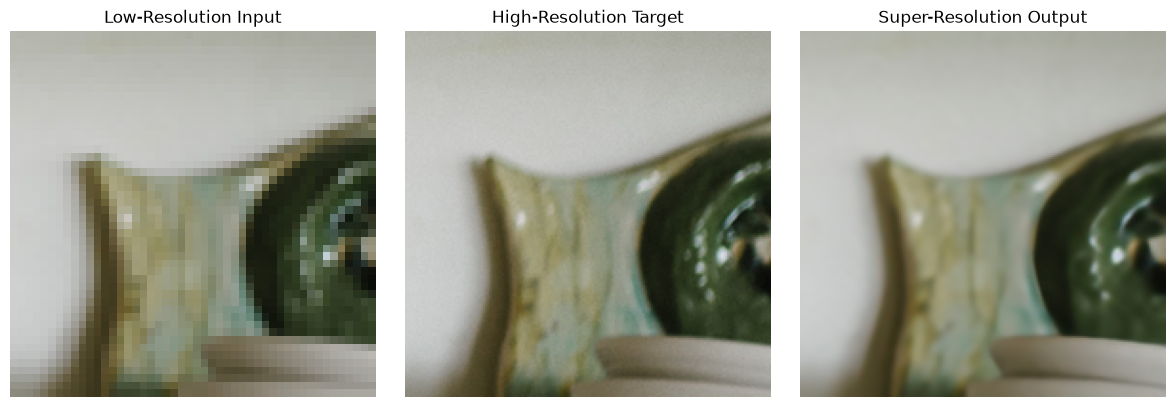

100%|██████████| 200/200 [01:12<00:00,  2.76it/s]


Epoch [5/200] Train Loss: 0.024133026 Val Loss: 0.024552170 Best: 0.024512463
Training time: 629.12s
--------------------------------------------------


100%|██████████| 200/200 [01:15<00:00,  2.66it/s]


Epoch [6/200] Train Loss: 0.026092717 Val Loss: 0.024531921 Best: 0.024512463
Training time: 771.46s
--------------------------------------------------


100%|██████████| 200/200 [01:17<00:00,  2.60it/s]


Epoch [7/200] Train Loss: 0.026370573 Val Loss: 0.024551649 Best: 0.024512463
Training time: 911.22s
--------------------------------------------------


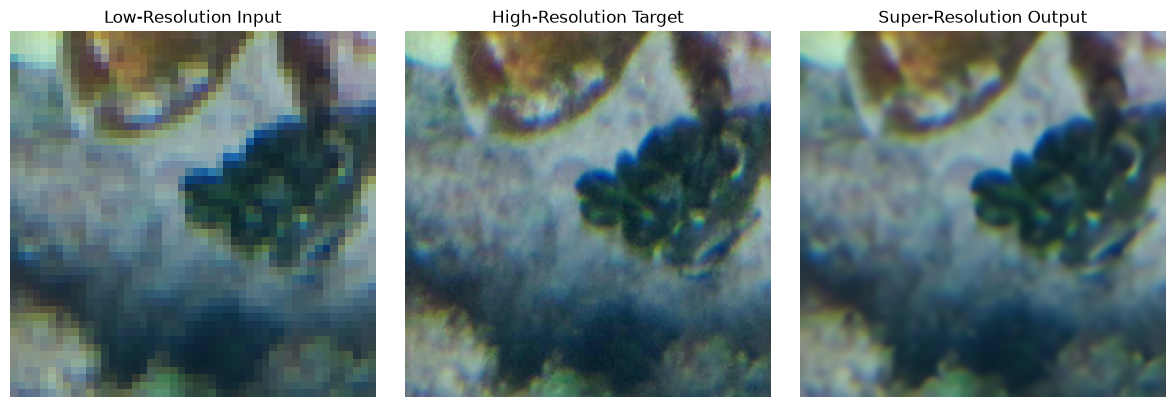

100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [8/200] Train Loss: 0.025743308 Val Loss: 0.024553900 Best: 0.024512463
Training time: 1040.79s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


Epoch [9/200] Train Loss: 0.026486609 Val Loss: 0.024555305 Best: 0.024512463
Training time: 1168.73s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [10/200] Train Loss: 0.025705763 Val Loss: 0.024571794 Best: 0.024512463
Training time: 1296.67s
--------------------------------------------------


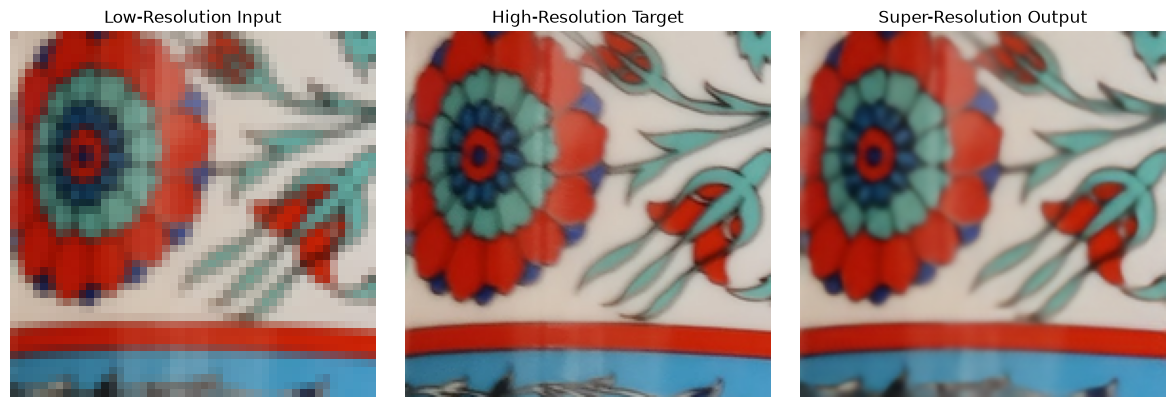

100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [11/200] Train Loss: 0.024974713 Val Loss: 0.024558843 Best: 0.024512463
Training time: 1424.67s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [12/200] Train Loss: 0.025417841 Val Loss: 0.024543166 Best: 0.024512463
Training time: 1551.98s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.72it/s]


Epoch [13/200] Train Loss: 0.025298589 Val Loss: 0.024528901 Best: 0.024512463
Training time: 1679.91s
--------------------------------------------------


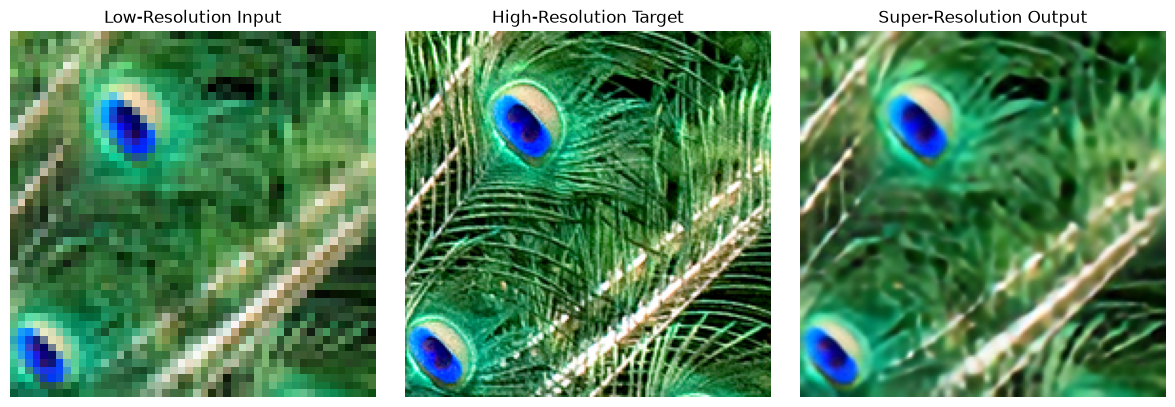

100%|██████████| 200/200 [01:13<00:00,  2.70it/s]


Epoch [14/200] Train Loss: 0.025006432 Val Loss: 0.024539251 Best: 0.024512463
Training time: 1807.51s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [15/200] Train Loss: 0.025396526 Val Loss: 0.024592096 Best: 0.024512463
Training time: 1935.87s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.67it/s]


Epoch [16/200] Train Loss: 0.024685438 Val Loss: 0.024551456 Best: 0.024512463
Training time: 2064.19s
--------------------------------------------------


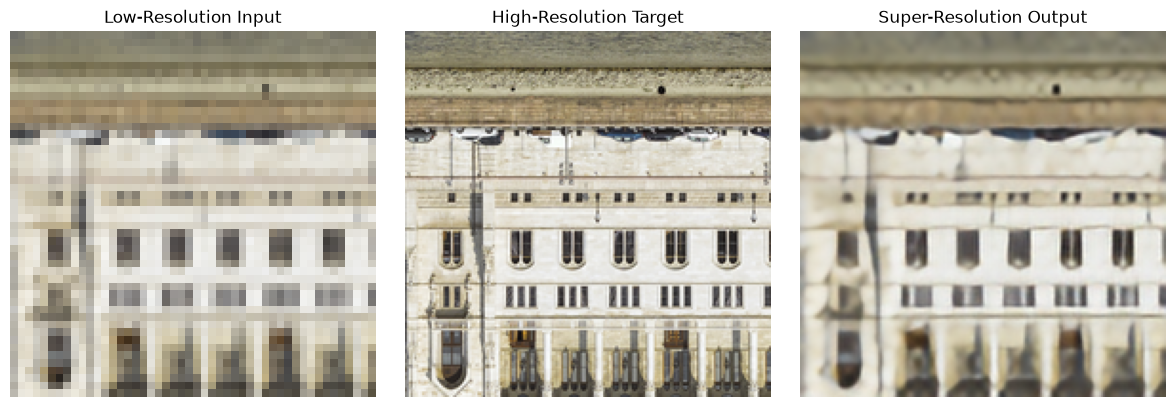

100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [17/200] Train Loss: 0.025296145 Val Loss: 0.024548102 Best: 0.024512463
Training time: 2193.16s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [18/200] Train Loss: 0.025843131 Val Loss: 0.024553229 Best: 0.024512463
Training time: 2319.75s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.70it/s]


Epoch [19/200] Train Loss: 0.025854191 Val Loss: 0.024546760 Best: 0.024512463
Training time: 2448.04s
--------------------------------------------------


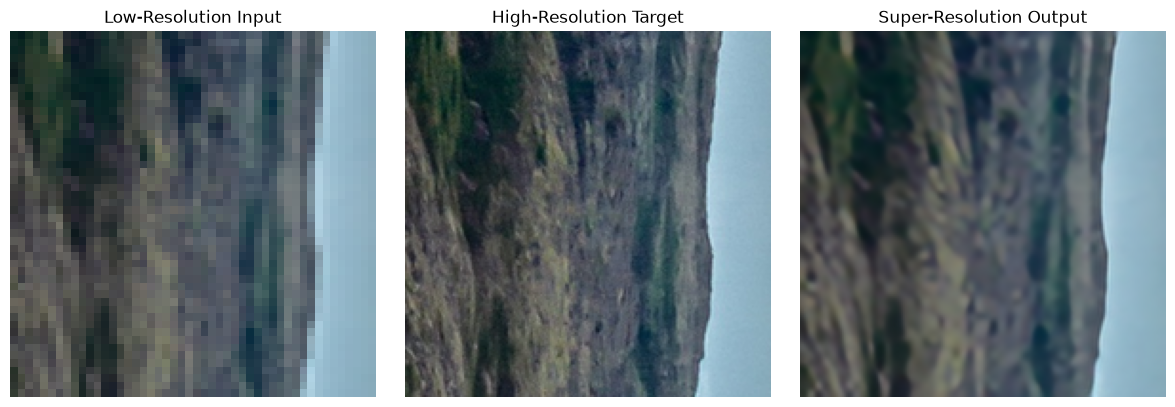

100%|██████████| 200/200 [01:13<00:00,  2.72it/s]


Epoch [20/200] Train Loss: 0.024807156 Val Loss: 0.024559205 Best: 0.024512463
Training time: 2574.53s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [21/200] Train Loss: 0.024329033 Val Loss: 0.024562337 Best: 0.024512463
Training time: 2702.57s
--------------------------------------------------


100%|██████████| 200/200 [01:15<00:00,  2.65it/s]


Epoch [22/200] Train Loss: 0.024558076 Val Loss: 0.024548692 Best: 0.024512463
Training time: 2831.55s
--------------------------------------------------


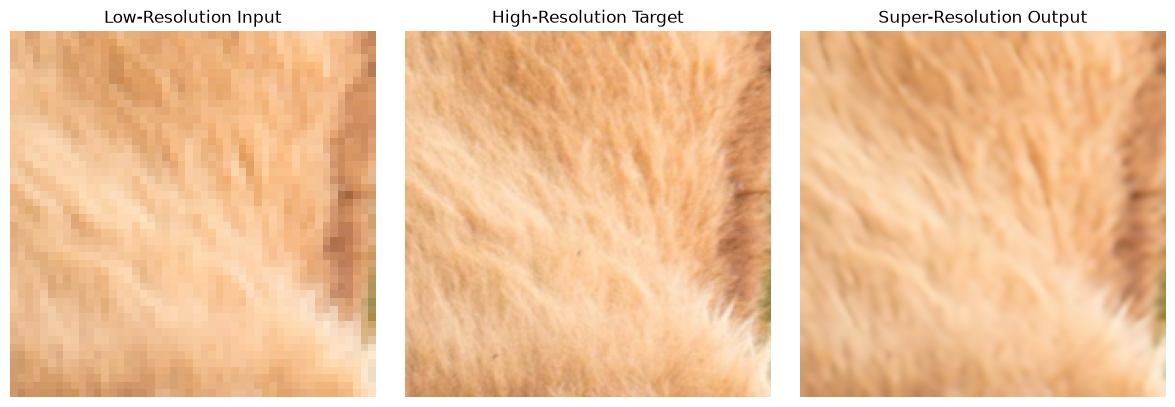

100%|██████████| 200/200 [01:13<00:00,  2.72it/s]


Epoch [23/200] Train Loss: 0.025577405 Val Loss: 0.024538098 Best: 0.024512463
Training time: 2962.72s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.72it/s]


Epoch [24/200] Train Loss: 0.025110513 Val Loss: 0.024560580 Best: 0.024512463
Training time: 3090.10s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


Epoch [25/200] Train Loss: 0.026028270 Val Loss: 0.024542314 Best: 0.024512463
Training time: 3217.91s
--------------------------------------------------


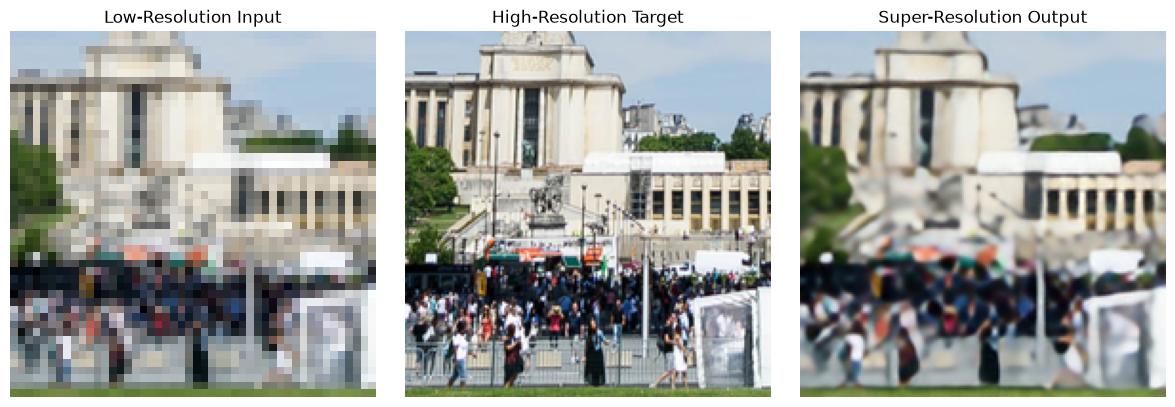

100%|██████████| 200/200 [01:13<00:00,  2.73it/s]


Epoch [26/200] Train Loss: 0.024795744 Val Loss: 0.024583095 Best: 0.024512463
Training time: 3345.53s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.72it/s]


Epoch [27/200] Train Loss: 0.024944870 Val Loss: 0.024533136 Best: 0.024512463
Training time: 3472.45s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [28/200] Train Loss: 0.025546820 Val Loss: 0.024566870 Best: 0.024512463
Training time: 3601.05s
--------------------------------------------------


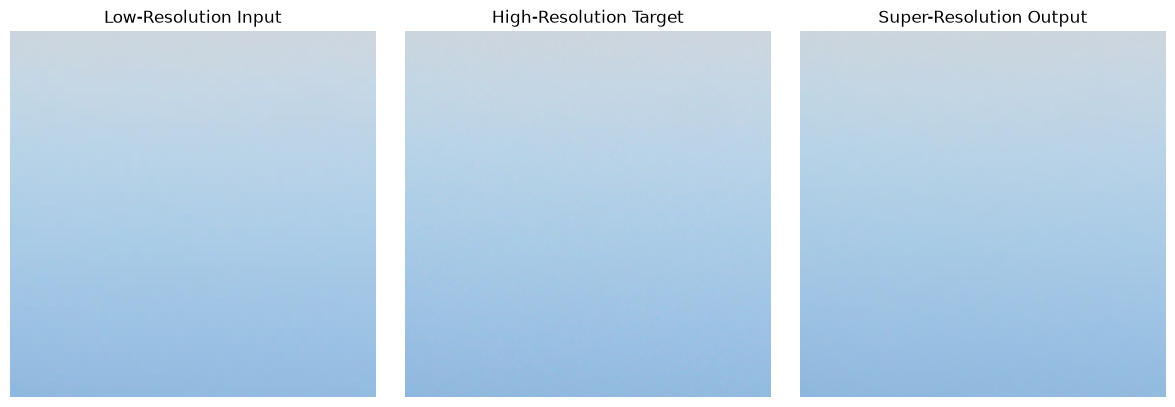

100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [29/200] Train Loss: 0.025186743 Val Loss: 0.024545719 Best: 0.024512463
Training time: 3728.35s
--------------------------------------------------


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


Epoch [30/200] Train Loss: 0.025431321 Val Loss: 0.024550699 Best: 0.024512463
Training time: 3857.04s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [31/200] Train Loss: 0.024722405 Val Loss: 0.024536722 Best: 0.024512463
Training time: 3984.93s
--------------------------------------------------


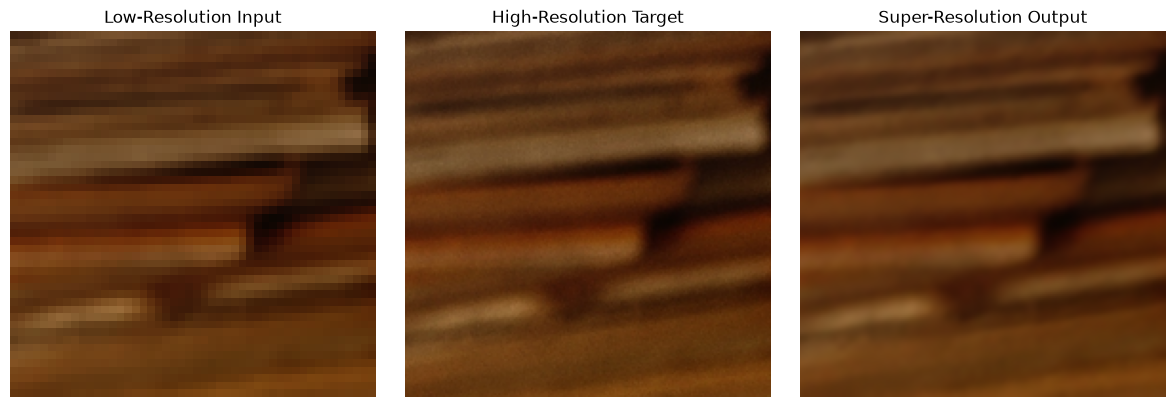

100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


Epoch [32/200] Train Loss: 0.025349907 Val Loss: 0.024533917 Best: 0.024512463
Training time: 4114.00s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.68it/s]


Epoch [33/200] Train Loss: 0.025446257 Val Loss: 0.024530731 Best: 0.024512463
Training time: 4241.36s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [34/200] Train Loss: 0.024994687 Val Loss: 0.024529156 Best: 0.024512463
Training time: 4370.66s
--------------------------------------------------


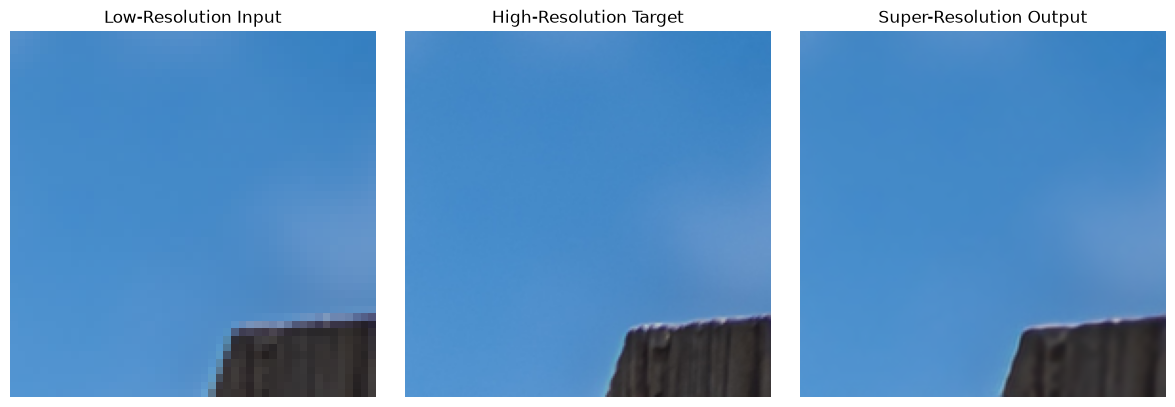

100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


Epoch [35/200] Train Loss: 0.025452743 Val Loss: 0.024543507 Best: 0.024512463
Training time: 4498.19s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [36/200] Train Loss: 0.025313458 Val Loss: 0.024540917 Best: 0.024512463
Training time: 4627.14s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [37/200] Train Loss: 0.025982008 Val Loss: 0.024538593 Best: 0.024512463
Training time: 4754.96s
--------------------------------------------------


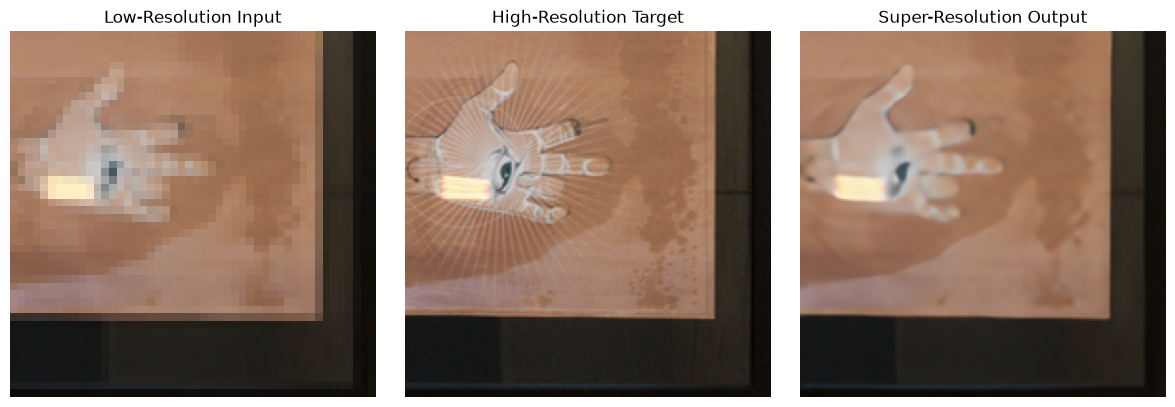

100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [38/200] Train Loss: 0.025422798 Val Loss: 0.024573171 Best: 0.024512463
Training time: 4884.33s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


Epoch [39/200] Train Loss: 0.025137478 Val Loss: 0.024553605 Best: 0.024512463
Training time: 5012.60s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [40/200] Train Loss: 0.025283135 Val Loss: 0.024570202 Best: 0.024512463
Training time: 5140.86s
--------------------------------------------------


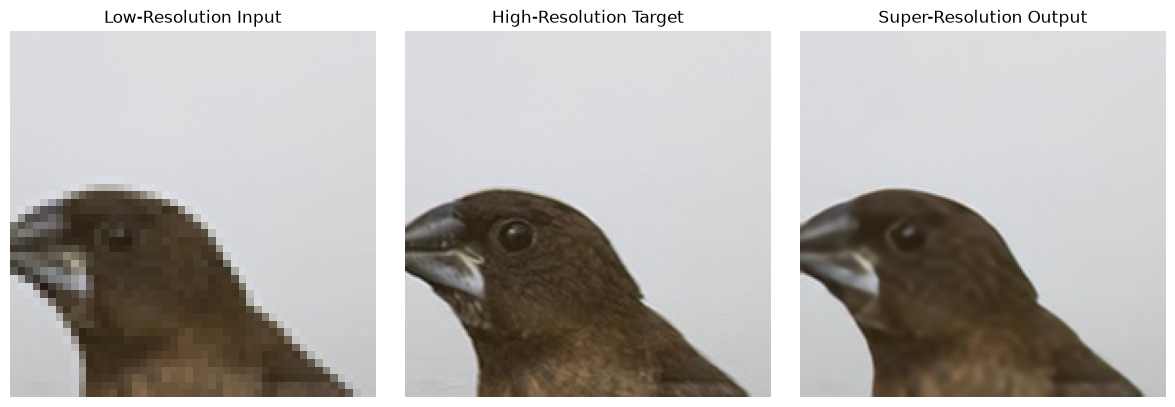

100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [41/200] Train Loss: 0.025606098 Val Loss: 0.024606957 Best: 0.024512463
Training time: 5269.91s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


Epoch [42/200] Train Loss: 0.025410187 Val Loss: 0.024517702 Best: 0.024512463
Training time: 5397.86s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.68it/s]


Epoch [43/200] Train Loss: 0.024484059 Val Loss: 0.024547188 Best: 0.024512463
Training time: 5526.81s
--------------------------------------------------


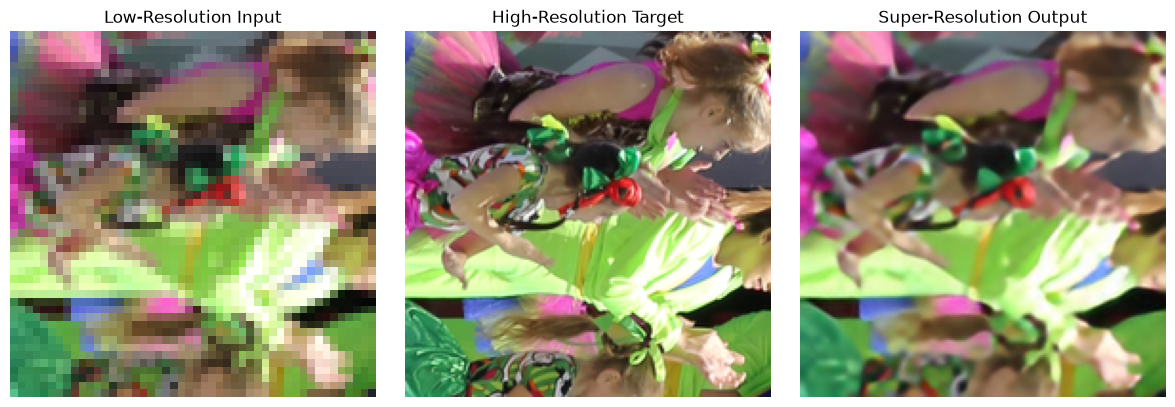

100%|██████████| 200/200 [01:14<00:00,  2.68it/s]


Epoch [44/200] Train Loss: 0.025633326 Val Loss: 0.024532940 Best: 0.024512463
Training time: 5654.75s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.68it/s]


Epoch [45/200] Train Loss: 0.025407059 Val Loss: 0.024555286 Best: 0.024512463
Training time: 5784.11s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.68it/s]


Epoch [46/200] Train Loss: 0.024248222 Val Loss: 0.024545150 Best: 0.024512463
Training time: 5911.55s
--------------------------------------------------


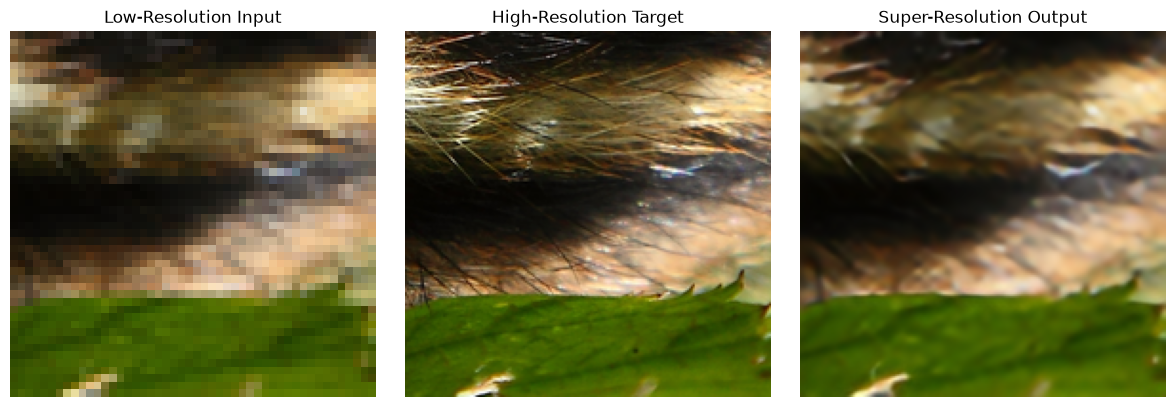

100%|██████████| 200/200 [01:14<00:00,  2.67it/s]


Epoch [47/200] Train Loss: 0.024490139 Val Loss: 0.024561200 Best: 0.024512463
Training time: 6041.52s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


Epoch [48/200] Train Loss: 0.025786453 Val Loss: 0.024543798 Best: 0.024512463
Training time: 6169.03s
--------------------------------------------------


100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


Epoch [49/200] Train Loss: 0.024549064 Val Loss: 0.024516899 Best: 0.024512463
Training time: 6298.14s
--------------------------------------------------


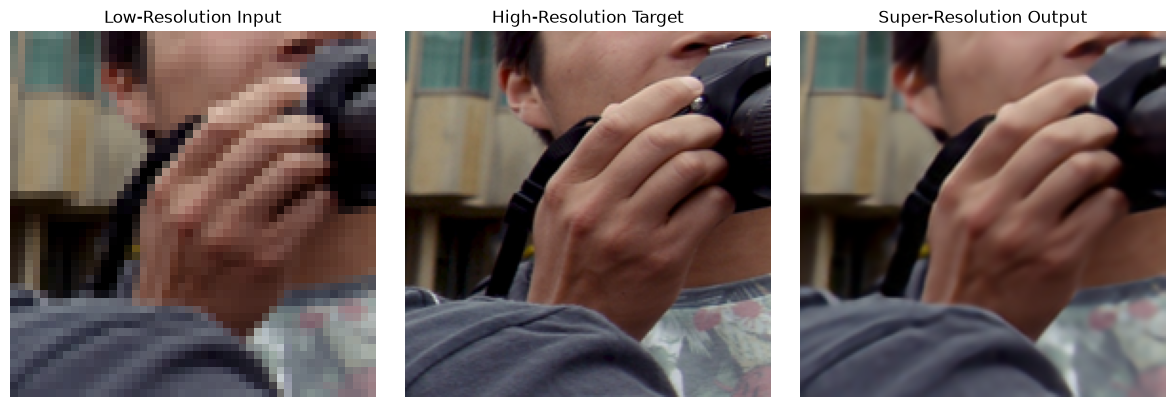

100%|██████████| 200/200 [01:17<00:00,  2.59it/s]

Early stopping triggered.


In [6]:
import random
import time
import matplotlib.pyplot as plt
patience = PATIENCE
baseline_loss = best_loss
train_losses = []
test_losses = []
time_start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for lr_images, hr_images in tqdm(train_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        optimizer.zero_grad()
        with autocast:
            outputs = model(lr_images)
            loss = criterion(outputs, hr_images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    #scheduler.step()

    # Validation
    model.eval()
    running_test_loss = 0.0
    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
                loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
    test_loss = running_test_loss / len(test_loader)
    test_losses.append(test_loss)

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(model.state_dict(), f"weights/faster_rcan_{STEP:02d}.pth")
    if test_loss > (baseline_loss + best_loss) / 2:
        patience -= 1
        if patience == 0:
            print("Early stopping triggered.")
            break
    else:
        patience = round(PATIENCE - (PATIENCE - 10) * (epoch + 1) / EPOCHS)
        patience = max(10, patience)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.9f} "
        f"Val Loss: {test_loss:.9f} "
        f"Best: {best_loss:.9f}"
    )
    print(f"Training time: {time.time() - time_start:.2f}s")
    print("-"*50)

    # Visualization
    if epoch % 3 == 0 or epoch == EPOCHS - 1:
        with torch.inference_mode():
            random_idx = random.randrange(len(train_dataset))
            lr_image, hr_image = train_dataset[random_idx]
            lr_input = lr_image.unsqueeze(0).to(device)
            output = model(lr_input).squeeze(0).cpu()
            lr_image = lr_image.cpu()
            hr_image = hr_image.cpu()
        # [C, H, W] -> [H, W, C]
        lr_image = lr_image.permute(1, 2, 0).numpy()
        hr_image = hr_image.permute(1, 2, 0).numpy()
        output = output.permute(1, 2, 0).numpy()
        # Clamp because model output can slightly exceed [0, 1]
        lr_image = lr_image.clip(0, 1)
        hr_image = hr_image.clip(0, 1)
        output = output.clip(0, 1)

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(lr_image)
        axs[0].set_title("Low-Resolution Input")
        axs[0].axis("off")

        axs[1].imshow(hr_image)
        axs[1].set_title("High-Resolution Target")
        axs[1].axis("off")

        axs[2].imshow(output)
        axs[2].set_title("Super-Resolution Output")
        axs[2].axis("off")

        plt.tight_layout()
        plt.show()

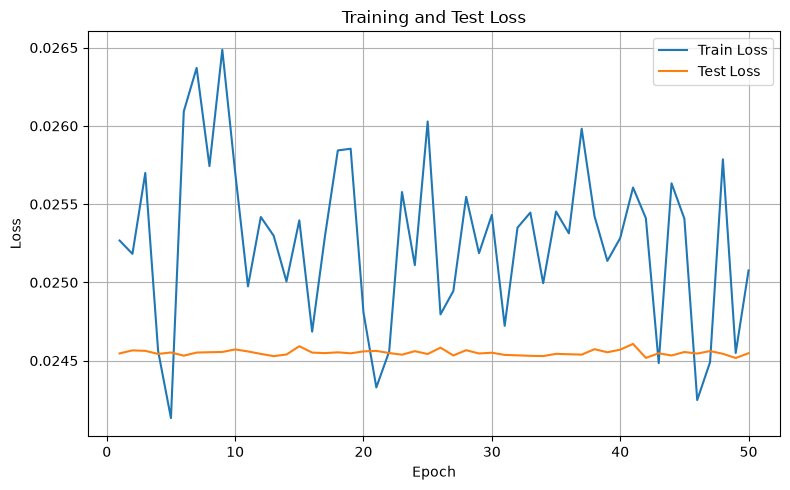

In [7]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import cv2
import numpy as np
from torchvision.transforms import v2
from skimage.metrics import structural_similarity as compare_ssim
def calculate_psnr(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf'),0  # Perfect match
    max_pixel = 1
    psnr = 10 * np.log10(max_pixel ** 2 / mse)
    return psnr,mse

def calculate_ssim(img1, img2, rgb=False):
    if rgb:
        img1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    ssim, _ = compare_ssim(img1, img2, full=True, data_range=1.0,)
    return ssim

to_tensor = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

In [9]:
model.load_state_dict(torch.load(f"weights/faster_rcan_{STEP:02d}.pth", map_location=device))

def evaluate_test_loader(test_loader):
    model.eval()

    psnr_scores = []
    ssim_scores = []

    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
            outputs = outputs.clamp(0, 1).float()
            # NCHW -> NHWC
            outputs = outputs.cpu().permute(0, 2, 3, 1).numpy()
            hr_images = hr_images.cpu().permute(0, 2, 3, 1).numpy()

            for output, hr in zip(outputs, hr_images):
                psnr, _ = calculate_psnr(output, hr)
                ssim = calculate_ssim(output, hr)

                psnr_scores.append(psnr)
                ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"PSNR: min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )
    print(
        f"SSIM: min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results
results = evaluate_test_loader(final_test_loader)

FileNotFoundError: [Errno 2] No such file or directory: 'weights/faster_rcan_07.pth'

In [ ]:
from PIL import Image
def evaluate_bicubic(test_loader):
    psnr_scores = []
    ssim_scores = []

    for lr_images, hr_images in tqdm(test_loader):
        for lr, hr in zip(lr_images, hr_images):
            lr = lr.permute(1, 2, 0).numpy()
            hr = hr.permute(1, 2, 0).numpy()

            # LR tensor [0,1] -> PIL
            lr_pil = Image.fromarray(
                (lr * 255).clip(0, 255).astype(np.uint8)
            )

            # PIL bicubic upscale
            bicubic_pil = lr_pil.resize(
                (hr.shape[1], hr.shape[0]),
                Image.Resampling.BICUBIC,
            )

            # PIL -> [0,1] float
            bicubic = np.asarray(bicubic_pil).astype(np.float32) / 255.0

            psnr, _ = calculate_psnr(bicubic, hr)
            ssim = calculate_ssim(bicubic, hr)

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"Bicubic PSNR: "
        f"min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )

    print(
        f"Bicubic SSIM: "
        f"min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results

bicubic_results = evaluate_bicubic(final_test_loader)

In [ ]:
import json

log = {
    "model_type": "FasterRCAN",
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "psnr": results["psnr"]["mean"],
    "ssim": results["ssim"]["mean"],
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(log) + "\n")